In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
DATA_PATH = r"C:\Users\ASUS\Desktop\Coding\Data Science Projects\customer_complaint\dataset"

In [4]:
import os

files = os.listdir(DATA_PATH)

print("Files in dataset folder:")
for file in files:
    print(file)

Files in dataset folder:
rows.csv


In [5]:
csv_files = [
    file for file in os.listdir(DATA_PATH)
    if file.lower().endswith(".csv")
]

print("CSV files found:", len(csv_files))

for file in csv_files:
    print(file)

CSV files found: 1
rows.csv


In [6]:
CSV_PATH = os.path.join(DATA_PATH, csv_files[0])

df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows    : 1282355
Number of columns : 18


In [8]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


In [9]:
df.tail()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
1282350,12/01/2011,Credit card,NaN,Credit determination,NaN,NaN,NaN,"CITIBANK, N.A.",MO,63301,NaN,NaN,Web,12/02/2011,Closed with relief,Yes,No,2396
1282351,12/01/2011,Mortgage,Conventional fixed mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,"BANK OF AMERICA, NATIONAL ASSOCIATION",OH,45248,NaN,NaN,Web,12/06/2011,Closed without relief,No,No,2323
1282352,12/01/2011,Credit card,NaN,Billing disputes,NaN,NaN,NaN,JPMORGAN CHASE & CO.,OH,43207,NaN,NaN,Referral,12/01/2011,Closed with relief,Yes,No,2126
1282353,12/01/2011,Mortgage,Conventional adjustable mortgage (ARM),"Loan servicing, payments, escrow account",NaN,NaN,NaN,"BANK OF AMERICA, NATIONAL ASSOCIATION",CO,80920,NaN,NaN,Web,12/01/2011,Closed with relief,Yes,No,2315
1282354,12/01/2011,Credit card,NaN,Billing disputes,NaN,NaN,NaN,"CITIBANK, N.A.",WA,98275,NaN,NaN,Web,12/11/2011,Closed with relief,Yes,No,2329


In [10]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. Date received
2. Product
3. Sub-product
4. Issue
5. Sub-issue
6. Consumer complaint narrative
7. Company public response
8. Company
9. State
10. ZIP code
11. Tags
12. Consumer consent provided?
13. Submitted via
14. Date sent to company
15. Company response to consumer
16. Timely response?
17. Consumer disputed?
18. Complaint ID


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 18 columns):
 #   Column                        Non-Null Count    Dtype
---  ------                        --------------    -----
 0   Date received                 1282355 non-null  str  
 1   Product                       1282355 non-null  str  
 2   Sub-product                   1047189 non-null  str  
 3   Issue                         1282355 non-null  str  
 4   Sub-issue                     751169 non-null   str  
 5   Consumer complaint narrative  383564 non-null   str  
 6   Company public response       449082 non-null   str  
 7   Company                       1282355 non-null  str  
 8   State                         1262955 non-null  str  
 9   ZIP code                      1167057 non-null  str  
 10  Tags                          175643 non-null   str  
 11  Consumer consent provided?    690654 non-null   str  
 12  Submitted via                 1282355 non-null  str  
 13  Date sen

In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df) * 100, 2), "%")

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [13]:
duplicate_ids = df["Complaint ID"].duplicated().sum()

print("Duplicate Complaint IDs:", duplicate_ids)

Duplicate Complaint IDs: 0


In [14]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
Tags,1106712,86.30
Consumer complaint narrative,898791,70.09
Company public response,833273,64.98
Consumer consent provided?,591701,46.14
Sub-issue,531186,41.42
Consumer disputed?,513854,40.07
Sub-product,235166,18.34
ZIP code,115298,8.99
State,19400,1.51
Date received,0,0.00


In [15]:
unique_counts = df.nunique().sort_values(ascending=False)

unique_counts

Complaint ID                    1282355
Consumer complaint narrative     366945
ZIP code                          22591
Company                            5275
Date received                      2717
Date sent to company               2666
Sub-issue                           218
Issue                               167
Sub-product                          76
State                                63
Product                              18
Company public response              10
Company response to consumer          8
Submitted via                         6
Consumer consent provided?            4
Tags                                  3
Timely response?                      2
Consumer disputed?                    2
dtype: int64

In [16]:
product_counts = df["Product"].value_counts()

print(product_counts)

Product
Mortgage                                                                        278098
Debt collection                                                                 244873
Credit reporting, credit repair services, or other personal consumer reports    225978
Credit reporting                                                                140432
Credit card                                                                      89190
Bank account or service                                                          86206
Student loan                                                                     51685
Credit card or prepaid card                                                      47653
Checking or savings account                                                      40641
Consumer Loan                                                                    31605
Vehicle loan or lease                                                            11377
Money transfer, virtual currency, o

In [17]:
product_distribution = pd.DataFrame({
    "Count": df["Product"].value_counts(),
    "Percentage": (df["Product"].value_counts(normalize=True) * 100).round(2)
})

product_distribution

,Count,Percentage
Product,,
Mortgage,278098,21.69
Debt collection,244873,19.10
"Credit reporting, credit repair services, or other personal consumer reports",225978,17.62
Credit reporting,140432,10.95
Credit card,89190,6.96
Bank account or service,86206,6.72
Student loan,51685,4.03
Credit card or prepaid card,47653,3.72
Checking or savings account,40641,3.17


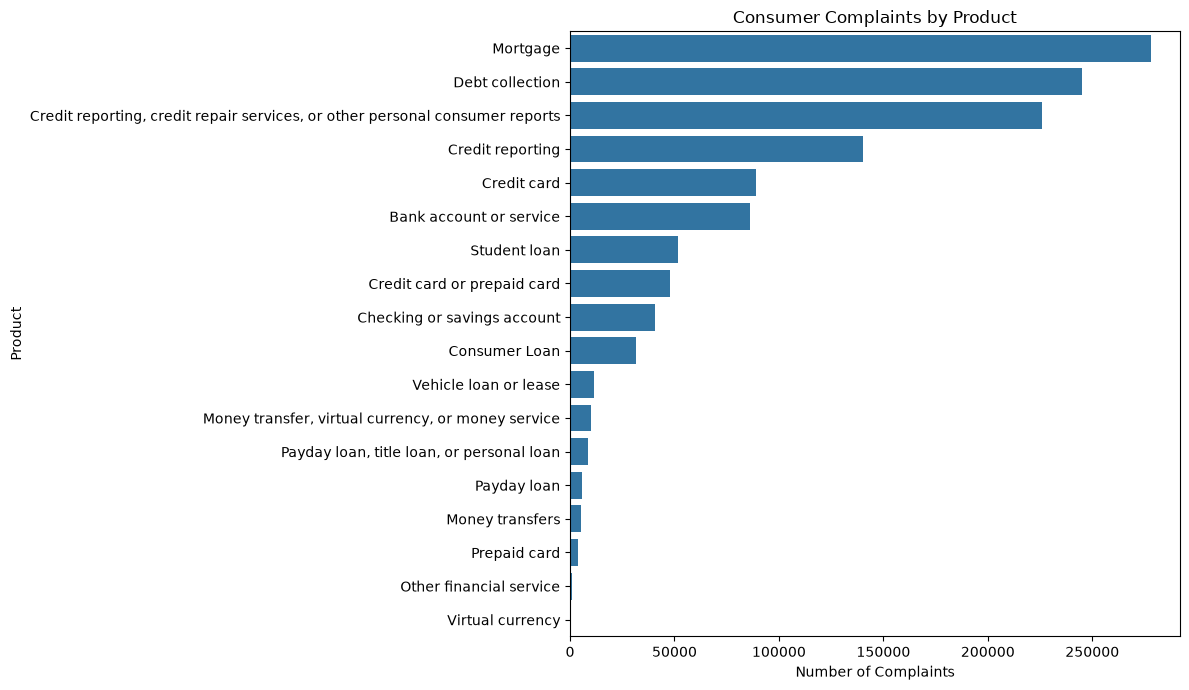

In [18]:
plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    y="Product",
    order=df["Product"].value_counts().index
)

plt.title("Consumer Complaints by Product")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [19]:
narrative_available = df["Consumer complaint narrative"].notna().sum()
narrative_missing = df["Consumer complaint narrative"].isna().sum()

print("Narrative available:", narrative_available)
print("Narrative missing  :", narrative_missing)

print(
    "\nNarrative availability:",
    round(narrative_available / len(df) * 100, 2), "%"
)

print(
    "Narrative missing:",
    round(narrative_missing / len(df) * 100, 2), "%"
)

Narrative available: 383564
Narrative missing  : 898791

Narrative availability: 29.91 %
Narrative missing: 70.09 %


In [20]:
text_df = df.dropna(subset=["Consumer complaint narrative"]).copy()

print("Rows with complaint narratives:", len(text_df))

text_product_distribution = pd.DataFrame({
    "Count": text_df["Product"].value_counts(),
    "Percentage": (
        text_df["Product"].value_counts(normalize=True) * 100
    ).round(2)
})

text_product_distribution

Rows with complaint narratives: 383564


,Count,Percentage
Product,,
"Credit reporting, credit repair services, or other personal consumer reports",92378,24.08
Debt collection,86710,22.61
Mortgage,52987,13.81
Credit reporting,31588,8.24
Student loan,21810,5.69
Credit card or prepaid card,21379,5.57
Credit card,18838,4.91
Bank account or service,14885,3.88
Checking or savings account,12881,3.36


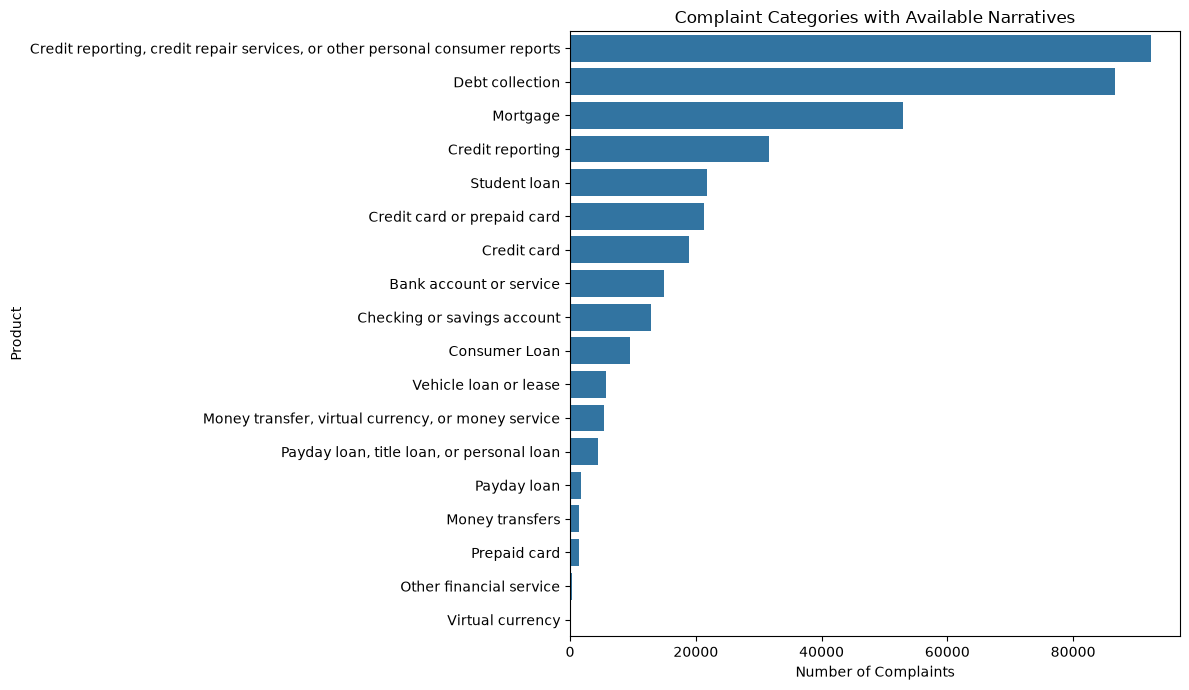

In [21]:
plt.figure(figsize=(12, 7))

sns.countplot(
    data=text_df,
    y="Product",
    order=text_df["Product"].value_counts().index
)

plt.title("Complaint Categories with Available Narratives")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [22]:
for i, product in enumerate(text_df["Product"].unique(), start=1):
    print(f"{i}. {product}")

1. Credit reporting, credit repair services, or other personal consumer reports
2. Debt collection
3. Student loan
4. Mortgage
5. Credit card or prepaid card
6. Checking or savings account
7. Money transfer, virtual currency, or money service
8. Vehicle loan or lease
9. Payday loan, title loan, or personal loan
10. Credit card
11. Bank account or service
12. Credit reporting
13. Consumer Loan
14. Prepaid card
15. Payday loan
16. Money transfers
17. Other financial service
18. Virtual currency


In [23]:
product_issue = pd.crosstab(
    text_df["Product"],
    text_df["Issue"]
)

product_issue.shape

(18, 161)

In [24]:
issue_counts = text_df["Issue"].value_counts()

issue_counts.head(20)

Issue
Incorrect information on your report                                                48773
Problem with a credit reporting company's investigation into an existing problem    24727
Incorrect information on credit report                                              21217
Attempts to collect debt not owed                                                   19845
Cont'd attempts collect debt not owed                                               17435
Improper use of your report                                                         15334
Loan servicing, payments, escrow account                                            14722
Communication tactics                                                               11506
Loan modification,collection,foreclosure                                            10790
Trouble during payment process                                                       9151
Written notification about debt                                                      8976
Fals

In [25]:
unique_issues_per_product = (
    text_df.groupby("Product")["Issue"]
    .nunique()
    .sort_values(ascending=False)
)

unique_issues_per_product

Product
Credit card                                                                     30
Payday loan, title loan, or personal loan                                       26
Credit card or prepaid card                                                     22
Credit reporting, credit repair services, or other personal consumer reports    20
Consumer Loan                                                                   18
Money transfer, virtual currency, or money service                              16
Mortgage                                                                        16
Checking or savings account                                                     12
Student loan                                                                    11
Debt collection                                                                 10
Vehicle loan or lease                                                           10
Other financial service                                                        

In [26]:
possible_groups = [
    [
        "Credit reporting",
        "Credit reporting, credit repair services, or other personal consumer reports"
    ],
    [
        "Credit card",
        "Credit card or prepaid card"
    ],
    [
        "Payday loan",
        "Payday loan, title loan, or personal loan"
    ],
    [
        "Money transfers",
        "Money transfer, virtual currency, or money service",
        "Virtual currency"
    ],
    [
        "Checking or savings account",
        "Bank account or service"
    ]
]

for group in possible_groups:
    print("\nGROUP:")
    for label in group:
        count = (text_df["Product"] == label).sum()
        print(f"{label}: {count}")


GROUP:
Credit reporting: 31588
Credit reporting, credit repair services, or other personal consumer reports: 92378

GROUP:
Credit card: 18838
Credit card or prepaid card: 21379

GROUP:
Payday loan: 1747
Payday loan, title loan, or personal loan: 4421

GROUP:
Money transfers: 1497
Money transfer, virtual currency, or money service: 5466
Virtual currency: 16

GROUP:
Checking or savings account: 12881
Bank account or service: 14885


In [27]:
text_df["text_length_chars"] = (
    text_df["Consumer complaint narrative"]
    .str.len()
)

text_df["text_length_chars"].describe()

count    383564.000000
mean       1082.011278
std        1173.511078
min           5.000000
25%         393.000000
50%         744.000000
75%        1363.000000
max       31735.000000
Name: text_length_chars, dtype: float64

In [28]:
text_df["text_length_words"] = (
    text_df["Consumer complaint narrative"]
    .str.split()
    .str.len()
)

text_df["text_length_words"].describe()

count    383564.000000
mean        196.822382
std         211.063970
min           1.000000
25%          71.000000
50%         136.000000
75%         249.000000
max        6314.000000
Name: text_length_words, dtype: float64

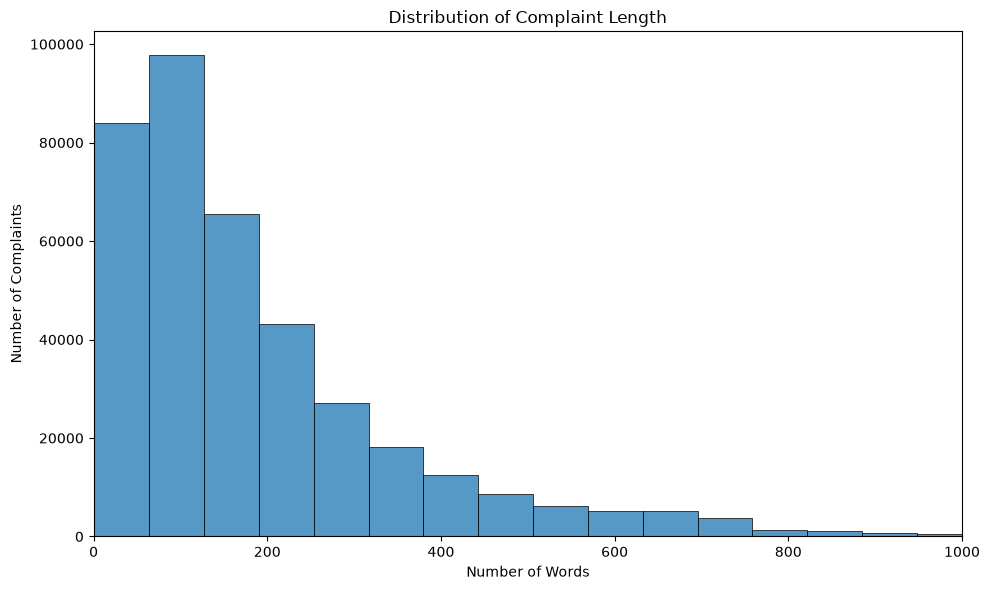

In [29]:
plt.figure(figsize=(10, 6))

sns.histplot(
    text_df["text_length_words"],
    bins=100
)

plt.xlim(0, 1000)

plt.title("Distribution of Complaint Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Complaints")

plt.tight_layout()
plt.show()

In [30]:
avg_length = (
    text_df.groupby("Product")["text_length_words"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

avg_length

,count,mean,median
Product,,,
Mortgage,52987,291.546266,215.0
Vehicle loan or lease,5745,269.730200,188.0
Checking or savings account,12881,259.515488,185.0
Credit card or prepaid card,21379,242.604893,179.0
Student loan,21810,232.933333,173.0
Bank account or service,14885,229.883440,176.0
Other financial service,292,229.061644,180.0
"Money transfer, virtual currency, or money service",5466,224.548664,159.0
"Payday loan, title loan, or personal loan",4421,214.380683,152.0


In [31]:
sample = text_df[
    ["Product", "Issue", "Consumer complaint narrative"]
].sample(10, random_state=42)

sample

,Product,Issue,Consumer complaint narrative
237049,Vehicle loan or lease,Managing the loan or lease,"I bought a XXXX XXXX XXXX with XXXX milies ont it from XXXX XXXX, the car currently has XXXX miles on it and is listed in the XXXX XXXX XXXX for only XXXX, but yet I'm paying {$400.00} a month f..."
819323,Mortgage,Settlement process and costs,"What happenedDescribe what happened so we can understand the issue ... \n\nSaturday XXXX XXXX, XXXX and major complaint. Previous complaints addressed harassing phone calls. You stated that no mor..."
678163,Credit reporting,Credit monitoring or identity protection,"On XXXX 2014 my SS was stolen & used, and my Computer was acked : finally 2 years later they have taken out a lot but there are still error I am XXXX years old. my car was in the shop for repairs ..."
755039,Credit reporting,Unable to get credit report/credit score,"I have requested my credit report from all XXXX agencies. The first time, I tried to do it online and I experienced computer errors, the 2nd time, I called in and followed the pronts. I only got X..."
297669,"Credit reporting, credit repair services, or other personal consumer reports",Improper use of your report,"CHEXSYSTEMS QUOTES RULES AND THIER PURPOSE WHICH I HAVE NO OBLIGATION TO PERFORM, CHEXXXXX OPERATES ON A PRESUMPTION, I DONT HAVE ANY CONTRACT WITH THESE DECEPTIVE MISCREANTS, CHEXSYSTEMS COMMITS ..."
867166,Mortgage,"Application, originator, mortgage broker",I am a XXXX in Indiana. My client is getting a loan through USAA Bank. He is a veteran. This loan has been dragging on for close to 50 days. Now they need to extend the rate lock but want to charg...
393523,Mortgage,Closing on a mortgage,"AS of XX/XX/2017, I am two weeks late on closing on my short sale because my mortgage company will not approve allowable charges under the terms of the loan. They are claiming HUD wont approve but..."
869618,Bank account or service,"Account opening, closing, or management","First Data Global Leasing/corporation did nothing but deceive from the XXXX meeting with company representative XXXX XXXX, promising a non existent manual processing machine ( "" XXXX '' ) for a tr..."
490713,"Credit reporting, credit repair services, or other personal consumer reports",Problem with a credit reporting company's investigation into an existing problem,Originally I had asked them to remove the charge off wording on my credit report and they say they ca n't but what I do n't understand is why they submitted the same charge-off again on my credit ...
789780,Bank account or service,"Account opening, closing, or management",I tried to close my checking acct with Santander in XXXX 2015. Unfortunately there was an ACH transaction that went thru a few weeks later from an acct I did n't realize was still active. Santande...


In [32]:
product_map = {
    "Credit reporting": "credit_reporting",
    "Credit reporting, credit repair services, or other personal consumer reports": "credit_reporting",

    "Credit card": "credit_card",
    "Credit card or prepaid card": "credit_card",

    "Payday loan": "loan",
    "Payday loan, title loan, or personal loan": "loan",
    "Consumer Loan": "loan",

    "Money transfers": "money_transfer",
    "Money transfer, virtual currency, or money service": "money_transfer",
    "Virtual currency": "money_transfer",

    "Checking or savings account": "bank_account",
    "Bank account or service": "bank_account",

    "Mortgage": "mortgage",
    "Debt collection": "debt_collection",
    "Student loan": "student_loan",
    "Vehicle loan or lease": "vehicle_loan",
    "Prepaid card": "prepaid_card",
    "Other financial service": "other"
}

In [33]:
text_df["Product_grouped"] = text_df["Product"].map(product_map)

In [34]:
print("Unmapped categories:")

print(
    text_df.loc[
        text_df["Product_grouped"].isna(),
        "Product"
    ].unique()
)

Unmapped categories:
<StringArray>
[]
Length: 0, dtype: str


In [35]:
grouped_counts = text_df["Product_grouped"].value_counts()

grouped_counts

Product_grouped
credit_reporting    123966
debt_collection      86710
mortgage             52987
credit_card          40217
bank_account         27766
student_loan         21810
loan                 15642
money_transfer        6979
vehicle_loan          5745
prepaid_card          1450
other                  292
Name: count, dtype: int64

In [36]:
grouped_distribution = pd.DataFrame({
    "Count": text_df["Product_grouped"].value_counts(),
    "Percentage": (
        text_df["Product_grouped"]
        .value_counts(normalize=True) * 100
    ).round(2)
})

grouped_distribution

,Count,Percentage
Product_grouped,,
credit_reporting,123966,32.32
debt_collection,86710,22.61
mortgage,52987,13.81
credit_card,40217,10.49
bank_account,27766,7.24
student_loan,21810,5.69
loan,15642,4.08
money_transfer,6979,1.82
vehicle_loan,5745,1.50


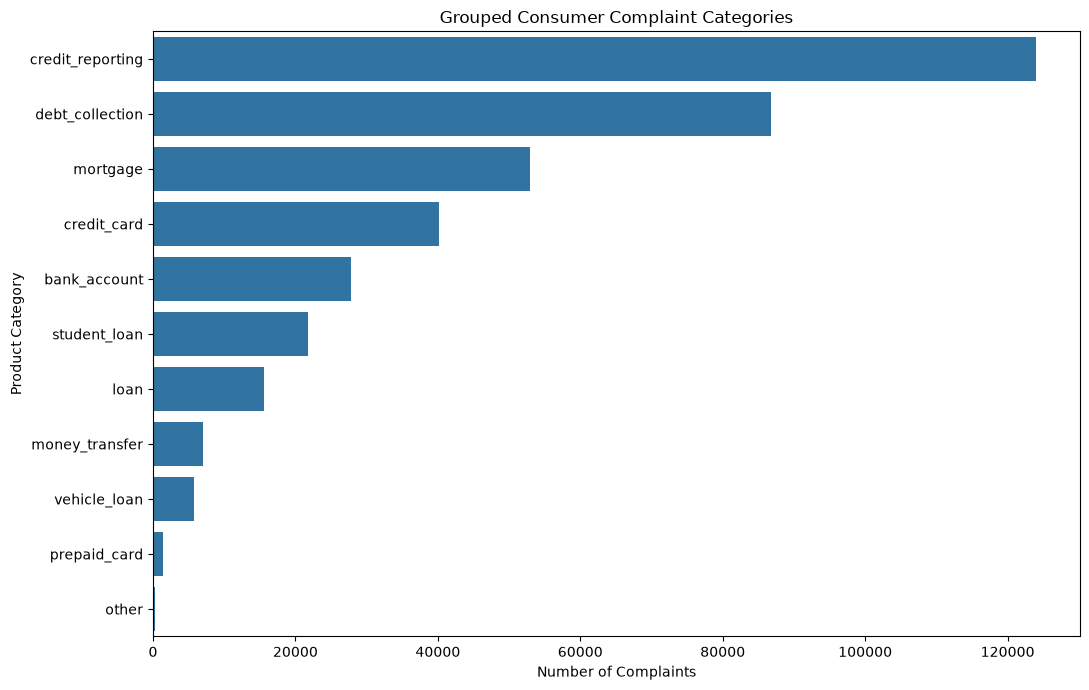

In [37]:
plt.figure(figsize=(11, 7))

sns.countplot(
    data=text_df,
    y="Product_grouped",
    order=text_df["Product_grouped"].value_counts().index
)

plt.title("Grouped Consumer Complaint Categories")
plt.xlabel("Number of Complaints")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [38]:
print("Original number of classes :", text_df["Product"].nunique())
print("Grouped number of classes  :", text_df["Product_grouped"].nunique())

Original number of classes : 18
Grouped number of classes  : 11


In [39]:
print(
    "Smallest class:",
    grouped_counts.min()
)

print(
    "Largest class:",
    grouped_counts.max()
)

Smallest class: 292
Largest class: 123966


In [40]:
imbalance_ratio = grouped_counts.max() / grouped_counts.min()

print(
    "Largest / Smallest class ratio:",
    round(imbalance_ratio, 2)
)

Largest / Smallest class ratio: 424.54


In [41]:
target_summary = (
    text_df.groupby("Product_grouped")
    .agg(
        complaints=("Product_grouped", "size"),
        avg_words=("text_length_words", "mean"),
        median_words=("text_length_words", "median")
    )
    .sort_values("complaints", ascending=False)
)

target_summary

,complaints,avg_words,median_words
Product_grouped,,,
credit_reporting,123966,149.528137,102.0
debt_collection,86710,161.146119,110.0
mortgage,52987,291.546266,215.0
credit_card,40217,226.235323,170.0
bank_account,27766,243.630123,181.0
student_loan,21810,232.933333,173.0
loan,15642,202.148383,147.0
money_transfer,6979,222.157043,159.0
vehicle_loan,5745,269.730200,188.0


In [42]:
model_df = text_df[
    [
        "Consumer complaint narrative",
        "Product_grouped"
    ]
].copy()

model_df.columns = ["text", "target"]

print("Shape:", model_df.shape)
model_df.head()

Shape: (383564, 2)


,text,target
29904,The Summer of XX/XX/2018 I was denied a mortgage loan due to a charge off from XXXX XXXX credit card. I both mailed an account validation letter and disputed this debt with the credit bureaus and ...,credit_reporting
30629,There are many mistakes appear in my report without my understanding.,credit_reporting
30735,There are many mistakes appear in my report without my understanding.,credit_reporting
30795,There are many mistakes appear in my report without my understanding.,credit_reporting
30807,There are many mistakes appear in my report without my understanding.,credit_reporting


In [43]:
model_df = model_df.dropna(subset=["text", "target"]).reset_index(drop=True)

print("Shape after removing missing values:", model_df.shape)
print("Missing values:")
print(model_df.isna().sum())

Shape after removing missing values: (383564, 2)
Missing values:
text      0
target    0
dtype: int64


In [44]:
duplicate_texts = model_df["text"].duplicated().sum()

print("Duplicate complaint texts:", duplicate_texts)
print(
    "Duplicate text percentage:",
    round(duplicate_texts / len(model_df) * 100, 2),
    "%"
)

Duplicate complaint texts: 16619
Duplicate text percentage: 4.33 %


In [45]:
model_df = (
    model_df
    .drop_duplicates(subset="text")
    .reset_index(drop=True)
)

print("Shape after removing duplicate texts:", model_df.shape)

Shape after removing duplicate texts: (366945, 2)


In [46]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

model_df["label"] = label_encoder.fit_transform(
    model_df["target"]
)

print("Label mapping:")

for label, class_name in enumerate(label_encoder.classes_):
    print(f"{label} → {class_name}")

Label mapping:
0 → bank_account
1 → credit_card
2 → credit_reporting
3 → debt_collection
4 → loan
5 → money_transfer
6 → mortgage
7 → other
8 → prepaid_card
9 → student_loan
10 → vehicle_loan


In [47]:
class_distribution = model_df["label"].value_counts().sort_index()

print(class_distribution)

label
0      27709
1      40015
2     110233
3      84277
4      15575
5       6967
6      52940
7        291
8       1447
9      21778
10      5713
Name: count, dtype: int64


In [48]:
from sklearn.model_selection import train_test_split

X = model_df["text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 293556
Testing samples : 73389


In [49]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples   :", len(X_test))

Training samples  : 234844
Validation samples: 58712
Testing samples   : 73389


In [50]:
print("TRAIN DISTRIBUTION")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nVALIDATION DISTRIBUTION")
print(y_val.value_counts(normalize=True).sort_index().round(3))

print("\nTEST DISTRIBUTION")
print(y_test.value_counts(normalize=True).sort_index().round(3))

TRAIN DISTRIBUTION
label
0     0.076
1     0.109
2     0.300
3     0.230
4     0.042
5     0.019
6     0.144
7     0.001
8     0.004
9     0.059
10    0.016
Name: proportion, dtype: float64

VALIDATION DISTRIBUTION
label
0     0.076
1     0.109
2     0.300
3     0.230
4     0.042
5     0.019
6     0.144
7     0.001
8     0.004
9     0.059
10    0.016
Name: proportion, dtype: float64

TEST DISTRIBUTION
label
0     0.076
1     0.109
2     0.300
3     0.230
4     0.042
5     0.019
6     0.144
7     0.001
8     0.004
9     0.059
10    0.016
Name: proportion, dtype: float64


In [51]:
print("=" * 50)
print("FINAL DATASET")
print("=" * 50)

print(f"Train      : {len(X_train):,}")
print(f"Validation : {len(X_val):,}")
print(f"Test       : {len(X_test):,}")
print(f"Total      : {len(X_train) + len(X_val) + len(X_test):,}")

print("\nNumber of classes:", len(label_encoder.classes_))

FINAL DATASET
Train      : 234,844
Validation : 58,712
Test       : 73,389
Total      : 366,945

Number of classes: 11


In [54]:
import os
import pickle

OUTPUT_PATH = r"C:\Users\ASUS\Desktop\Coding\Data Science Projects\customer_complaint\outputs"

os.makedirs(OUTPUT_PATH, exist_ok=True)

# Save text splits
X_train.to_csv(
    os.path.join(OUTPUT_PATH, "X_train.csv"),
    index=False,
    header=True
)

X_val.to_csv(
    os.path.join(OUTPUT_PATH, "X_val.csv"),
    index=False,
    header=True
)

X_test.to_csv(
    os.path.join(OUTPUT_PATH, "X_test.csv"),
    index=False,
    header=True
)

# Save label splits
y_train.to_csv(
    os.path.join(OUTPUT_PATH, "y_train.csv"),
    index=False,
    header=True
)

y_val.to_csv(
    os.path.join(OUTPUT_PATH, "y_val.csv"),
    index=False,
    header=True
)

y_test.to_csv(
    os.path.join(OUTPUT_PATH, "y_test.csv"),
    index=False,
    header=True
)

# Save label encoder
with open(
    os.path.join(OUTPUT_PATH, "label_encoder.pkl"),
    "wb"
) as f:
    pickle.dump(label_encoder, f)

print("All processed datasets saved successfully.")

All processed datasets saved successfully.


In [53]:
import pickle

with open(os.path.join(OUTPUT_PATH, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved.")

Label encoder saved.
